<div style="background:linear-gradient(90deg,#E23744,#B71C1C);
padding:25px;
border-radius:12px;
text-align:center;
color:white;">

<h1>🍽️ Zomato Restaurant Data Analysis (EDA)</h1>

<h3>Exploratory Data Analysis of Zomato Restaurant Reviews and Metadata</h3>

</div>

<br>

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🎯 Project Objective
</h2>

<p style="font-size:16px; line-height:1.8;">

The objective of this project is to perform <b>Exploratory Data Analysis (EDA)</b> on the Zomato restaurant dataset to understand customer ratings, restaurant costs, cuisines, reviews, and identify meaningful patterns and business insights. The analysis helps in understanding customer preferences and restaurant performance using data visualization techniques.

</p>

<br>

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📂 Dataset Information
</h2>

<p style="font-size:16px; line-height:1.8;">

This project uses two datasets:

</p>

<ul style="font-size:16px; line-height:2;">
<li><b>Zomato Restaurant Reviews</b> – Contains customer reviews, ratings, review time, reviewer details, and pictures.</li>

<li><b>Zomato Restaurant Names and Metadata</b> – Contains restaurant name, cost, cuisines, collections, timings, and other restaurant information.</li>
</ul>

<hr>

<p align="center" style="color:gray;">
Prepared for <b>Zomato Restaurant Clustering Project</b>
</p>

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📚 Import Required Libraries
</h2>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

plt.rcParams['figure.figsize'] = (10, 6)

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📂 Load the Datasets
</h2>

<p style="font-size:16px; line-height:1.8;">

In this step, we load the two datasets used in the project:
<ul>
<li><b>Zomato Restaurant Reviews</b></li>
<li><b>Zomato Restaurant Names and Metadata</b></li>
</ul>

</p>

In [5]:
reviews_df = pd.read_csv("Zomato Restaurant reviews.csv")
metadata_df = pd.read_csv("Zomato Restaurant names and Metadata.csv")

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
👀 Display the First Five Rows
</h2>

In [6]:
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Observation

- The first five rows of the restaurant reviews dataset are displayed successfully.
- The dataset contains customer review information such as restaurant name, reviewer name, rating, review text, review time, and pictures.
- This step helps in understanding the structure of the dataset before performing further analysis.

In [7]:
metadata_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


### Observation

- The first five rows of the restaurant metadata dataset are displayed successfully.
- The dataset contains restaurant details such as restaurant name, cuisines, cost, collections, timings, and links.
- This provides a clear overview of the restaurant information available for analysis.


<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📊 Dataset Shape
</h2>

<p style="font-size:16px; line-height:1.8;">
The shape of the dataset represents the number of rows and columns present in each dataset.
</p>

In [8]:
print("Reviews Dataset Shape:", reviews_df.shape)
print("Metadata Dataset Shape:", metadata_df.shape)

Reviews Dataset Shape: (10000, 7)
Metadata Dataset Shape: (105, 6)


### Observation

- The reviews dataset contains **_10000__ rows** and **_7__ columns**.
- The metadata dataset contains **_105__ rows** and **__6_ columns**.
- Both datasets contain a sufficient number of records for performing exploratory data analysis.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📋 Dataset Columns
</h2>

<p style="font-size:16px; line-height:1.8;">
This step displays the names of all columns available in each dataset.
</p>

In [9]:
print("Reviews Dataset Columns")
print(reviews_df.columns)

print("\nMetadata Dataset Columns")
print(metadata_df.columns)

Reviews Dataset Columns
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='str')

Metadata Dataset Columns
Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='str')


### Observation

- The reviews dataset contains columns related to customer reviews and ratings.
- The metadata dataset contains columns describing restaurant information such as cuisines, cost, timings, and collections.
- Understanding column names helps in selecting relevant features for analysis.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📑 Dataset Information
</h2>

<p style="font-size:16px; line-height:1.8;">
This step provides detailed information about the dataset, including the number of entries, column names, data types, and non-null values.
</p>

In [10]:
print("Reviews Dataset Information")
reviews_df.info()

Reviews Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Restaurant  10000 non-null  str  
 1   Reviewer    9962 non-null   str  
 2   Review      9955 non-null   str  
 3   Rating      9962 non-null   str  
 4   Metadata    9962 non-null   str  
 5   Time        9962 non-null   str  
 6   Pictures    10000 non-null  int64
dtypes: int64(1), str(6)
memory usage: 3.8 MB


### Observation

- The reviews dataset contains **10,000 records** and **7 columns**.
- Most columns have the **object** data type, while the **Pictures** column is of **integer** type.
- A few missing values are present in the **Reviewer, Review, Rating, Metadata, and Time** columns.
- This dataset mainly contains customer review and rating information.

In [11]:
print("\nMetadata Dataset Information")
metadata_df.info()


Metadata Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         105 non-null    str  
 1   Links        105 non-null    str  
 2   Cost         105 non-null    str  
 3   Collections  51 non-null     str  
 4   Cuisines     105 non-null    str  
 5   Timings      104 non-null    str  
dtypes: str(6)
memory usage: 21.5 KB


### Observation

- The metadata dataset contains **105 records** and **6 columns**.
- All columns are of the **object** data type.
- The **Collections** column contains a significant number of missing values, while the **Timings** column has only a few missing values.
- This dataset provides restaurant details such as name, cost, cuisines, timings, and collections.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔍 Missing Values Analysis
</h2>

<p style="font-size:16px; line-height:1.8;">
This step identifies missing values present in each column of both datasets.
</p>

In [12]:
print("Missing Values in Reviews Dataset")
reviews_df.isnull().sum()

Missing Values in Reviews Dataset


Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

### Observation

- The **Restaurant** and **Pictures** columns do not contain any missing values.
- The **Reviewer**, **Rating**, **Metadata**, and **Time** columns each contain **38 missing values**.
- The **Review** column contains **45 missing values**, which is the highest among all columns in the reviews dataset.
- These missing values need to be handled before performing further analysis to ensure accurate results.

In [13]:
metadata_df.isnull().sum()

Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

### Observation

- The **Name**, **Links**, **Cost**, and **Cuisines** columns do not contain any missing values.
- The **Collections** column contains **54 missing values**, which is the highest in the metadata dataset.
- The **Timings** column contains only **1 missing value**.
- The missing values in the **Collections** and **Timings** columns should be handled before further analysis.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔄 Duplicate Values Analysis
</h2>

<p style="font-size:16px; line-height:1.8;">
This step checks whether the datasets contain duplicate records that may affect the analysis.
</p>

In [14]:
print("Duplicate Values in Reviews Dataset:", reviews_df.duplicated().sum())

Duplicate Values in Reviews Dataset: 36


### Observation

- The reviews dataset contains **36 duplicate records**.
- Duplicate records can lead to biased analysis and incorrect insights.
- The metadata dataset does not contain any duplicate records.
- The duplicate rows from the reviews dataset should be removed before proceeding with further analysis.

In [15]:
print("Duplicate Values in Metadata Dataset:", metadata_df.duplicated().sum())

Duplicate Values in Metadata Dataset: 0


### Observation

- The reviews dataset contains **36 duplicate records**.
- The metadata dataset does not contain any duplicate records.
- Duplicate records in the reviews dataset may affect the analysis and should be removed.
- Therefore, duplicate rows will be removed before proceeding with further analysis.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🧹 Remove Duplicate Records
</h2>

<p style="font-size:16px; line-height:1.8;">
In this step, duplicate records are removed from the dataset to improve data quality and ensure accurate analysis.
</p>

In [16]:
reviews_df.drop_duplicates(inplace=True)
metadata_df.drop_duplicates(inplace=True)

print("Reviews Dataset Shape:", reviews_df.shape)
print("Metadata Dataset Shape:", metadata_df.shape)

Reviews Dataset Shape: (9964, 7)
Metadata Dataset Shape: (105, 6)


### Observation

- After removing duplicate records, the reviews dataset now contains **9,964 rows** and **7 columns**.
- The metadata dataset still contains **105 rows** and **6 columns**, as no duplicate records were found.
- The datasets are now cleaner and ready for handling missing values before performing Exploratory Data Analysis (EDA).

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔍 Handling Missing Values
</h2>

<p style="font-size:16px; line-height:1.8;">
In this step, missing values are handled to improve the quality of the dataset and ensure reliable analysis.
</p>

In [17]:
reviews_df.isnull().sum()

Restaurant    0
Reviewer      2
Review        9
Rating        2
Metadata      2
Time          2
Pictures      0
dtype: int64

### Observation

- After removing duplicate records, the number of missing values in the reviews dataset decreased significantly.
- The **Restaurant** and **Pictures** columns do not contain any missing values.
- Only a few missing values remain in the **Reviewer (2)**, **Review (9)**, **Rating (2)**, **Metadata (2)**, and **Time (2)** columns.
- Since the remaining missing values represent a very small portion of the dataset, these records can be safely removed without affecting the overall analysis.

In [18]:
reviews_df.dropna(inplace=True)
reviews_df.isnull().sum()

Restaurant    0
Reviewer      0
Review        0
Rating        0
Metadata      0
Time          0
Pictures      0
dtype: int64

### Observation

- Missing values have been successfully removed from the reviews dataset.
- Since the number of missing records was very small compared to the total dataset, removing them does not significantly affect the analysis.
- The reviews dataset is now clean and ready for Exploratory Data Analysis (EDA).

In [19]:
metadata_df.isnull().sum()

Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

### Observation

- The **Name**, **Links**, **Cost**, and **Cuisines** columns do not contain any missing values.
- The **Collections** column contains **54 missing values**, which is more than 50% of the dataset.
- The **Timings** column contains only **1 missing value**.
- Since the **Collections** column has a large number of missing values, replacing the missing values with **"Not Available"** is more appropriate than removing the rows. The single missing value in the **Timings** column can be removed without significantly affecting the dataset.

In [20]:
metadata_df["Collections"] = metadata_df["Collections"].fillna("Not Available")

metadata_df.dropna(subset=["Timings"], inplace=True)

metadata_df.isnull().sum()

Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64

### Observation

- All missing values have been successfully handled in the metadata dataset.
- No missing values are present in any of the columns.
- The dataset is now clean and ready for further exploratory data analysis (EDA).

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔍 Check Unique Values in the Rating Column
</h2>

<p style="font-size:16px; line-height:1.8;">
This step is performed to identify all unique values present in the <b>Rating</b> column. It helps detect inconsistent or non-numeric values before data type conversion.
</p>

In [21]:
reviews_df["Rating"].unique()

<ArrowStringArray>
['5', '4', '1', '3', '2', '3.5', '4.5', '2.5', '1.5', 'Like']
Length: 10, dtype: str

### Observation

- The **Rating** column contains **10 unique values**.
- Most values are numeric ratings such as **1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, and 5**.
- A non-numeric value **"Like"** is also present in the column.
- Since **"Like"** is not a valid numeric rating, it should be removed before converting the column to a numeric data type.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🗑️ Remove Non-Numeric Values
</h2>

<p style="font-size:16px; line-height:1.8;">
The <b>Rating</b> column contains a non-numeric value (<b>"Like"</b>), which is removed before numerical analysis.
</p>

In [22]:
reviews_df = reviews_df[reviews_df["Rating"] != "Like"]

### Observation

- The non-numeric value **"Like"** was successfully removed from the **Rating** column.
- This ensures that only valid numerical ratings remain in the dataset.
- The dataset is now ready for data type conversion.

In [23]:
reviews_df["Rating"] = reviews_df["Rating"].astype(float)

### Observation

- The **Rating** column has been successfully converted to the **float** data type.
- This conversion enables numerical calculations and accurate visualizations.
- The dataset is now suitable for Exploratory Data Analysis (EDA).

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
✅ Verify Data Type Conversion
</h2>

<p style="font-size:16px; line-height:1.8;">
This step verifies that the <b>Rating</b> column has been successfully converted to a numeric data type. It also displays the first few values to confirm the conversion.
</p>

In [24]:
print("Data Type:", reviews_df["Rating"].dtype)
print("\nFirst 5 Ratings:")
print(reviews_df["Rating"].head())

Data Type: float64

First 5 Ratings:
0    5.0
1    5.0
2    5.0
3    5.0
4    5.0
Name: Rating, dtype: float64


### Observation

- The **Rating** column has been successfully converted to the **float64** data type.
- The first five values confirm that the ratings are now stored as numeric values.
- The dataset is now ready for numerical analysis and visualization.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📊 EDA 1: Rating Distribution
</h2>

<p style="font-size:16px; line-height:1.8;">
This histogram shows the distribution of customer ratings across restaurants. It helps identify the most common rating values and understand the overall customer satisfaction.
</p>

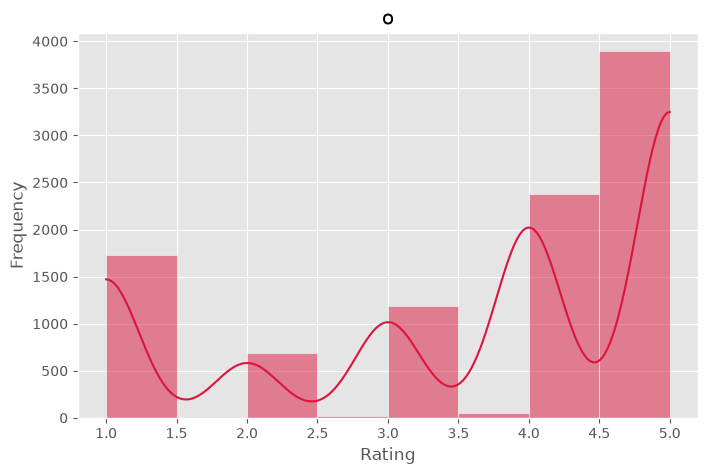

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=reviews_df,
    x="Rating",
    bins=8,
    kde=True,
    color="crimson"
)

plt.title("o")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

### Observation

- The distribution of restaurant ratings is skewed towards higher ratings.
- Most restaurants have ratings between **4.0 and 5.0**, indicating generally positive customer feedback.
- Ratings below **3.0** are comparatively less frequent.
- The highest concentration of ratings is around **5.0**, suggesting that many customers gave excellent ratings to restaurants.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📊 EDA 2: Customer Rating Count
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization displays the number of restaurants for each rating value. It helps identify which ratings are most frequently given by customers.
</p>

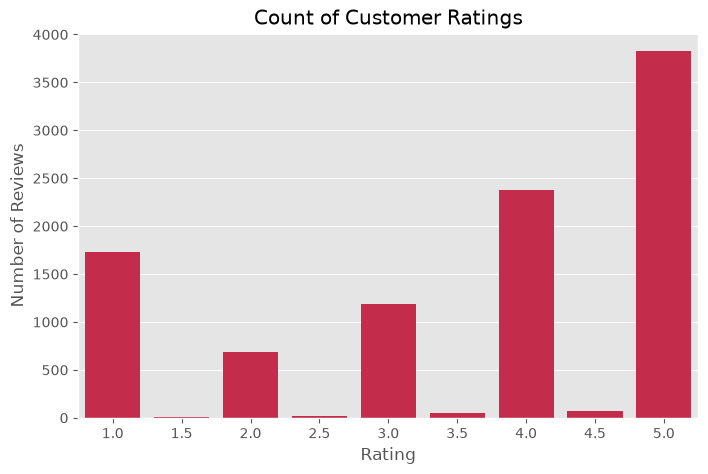

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews_df,
    x="Rating",
    order=sorted(reviews_df["Rating"].unique()),
    color="crimson"
)

plt.title("Count of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

### Observation

- The **5.0** rating has the highest number of reviews, making it the most frequently assigned rating.
- The **4.0** rating is the second most common, indicating that many customers are satisfied with restaurant services.
- Ratings **1.0**, **2.0**, and **3.0** occur less frequently compared to higher ratings.
- The **1.5**, **2.5**, **3.5**, and **4.5** ratings have very few reviews.
- Overall, the distribution indicates that customers generally give higher ratings, reflecting a positive perception of restaurants.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
👤 EDA 3: Top 10 Most Active Reviewers
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization identifies the top 10 reviewers who have submitted the highest number of restaurant reviews.
</p>

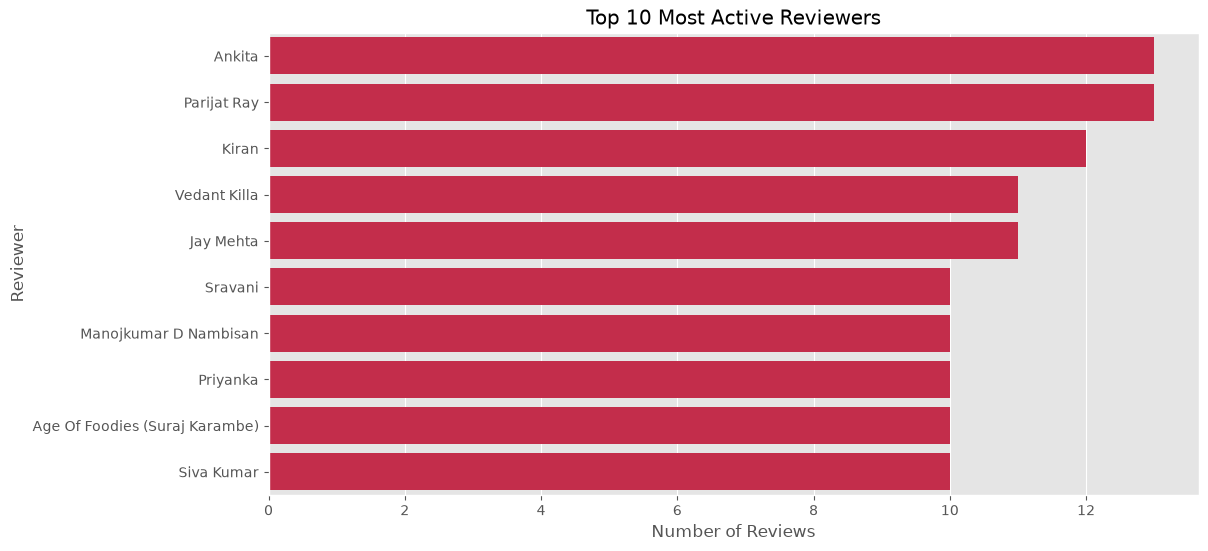

In [27]:
top_reviewers = reviews_df["Reviewer"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index,
    color="crimson"
)

plt.title("Top 10 Most Active Reviewers")
plt.xlabel("Number of Reviews")
plt.ylabel("Reviewer")

plt.show()

### Observation

- The graph highlights the top 10 most active reviewers based on the number of reviews submitted.
- **Ankita** and **Parijat Ray** are the most active reviewers, each contributing the highest number of reviews.
- **Kiran**, **Vedant Killa**, and **Jay Mehta** also have a significant number of reviews compared to other reviewers.
- The remaining reviewers have slightly fewer reviews but are still among the top contributors in the dataset.
- Identifying active reviewers helps understand customer engagement and review contribution patterns.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
⭐ EDA 4: Top 10 Highest Rated Restaurants
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization shows the top 10 restaurants with the highest average customer ratings. It helps identify the best-performing restaurants based on customer feedback.
</p>

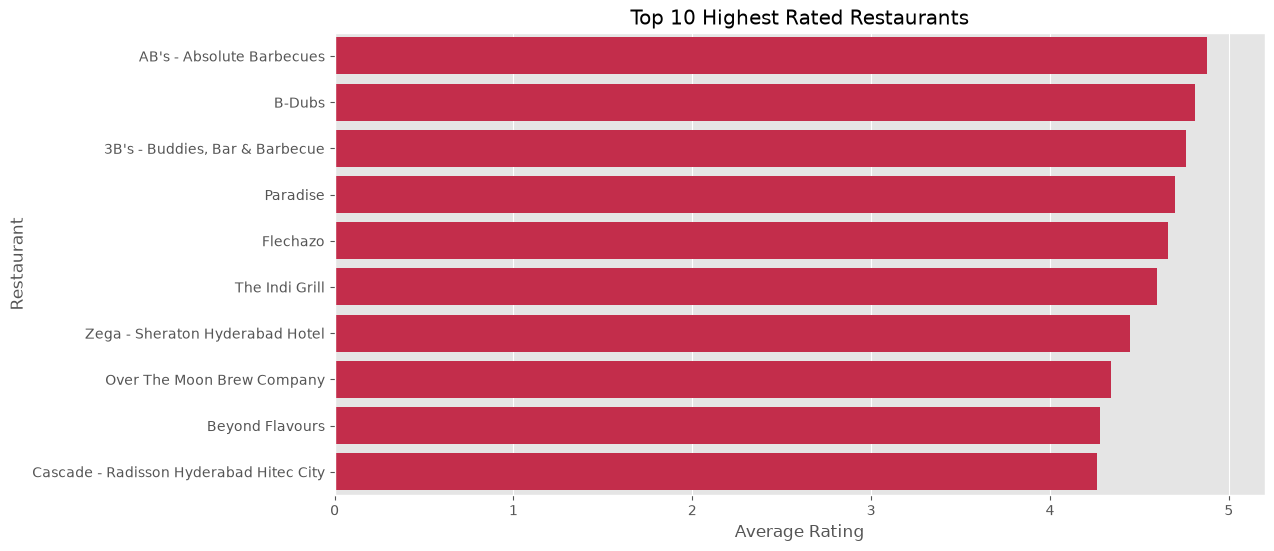

In [28]:
top_rated = (
    reviews_df.groupby("Restaurant")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_rated.values,
    y=top_rated.index,
    color="crimson"
)

plt.title("Top 10 Highest Rated Restaurants")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant")

plt.xlim(0, 5.2)

plt.show()

### Observation

- The graph shows the top 10 restaurants with the highest average customer ratings.
- **AB's - Absolute Barbecues** has the highest average rating, followed closely by **B-Dubs** and **3B's - Buddies, Bar & Barbecue**.
- All the top-rated restaurants have an average rating above **4.2**, indicating a high level of customer satisfaction.
- The small difference in average ratings suggests that these restaurants consistently provide good service and dining experiences.
- Customer ratings can be considered an important factor for identifying high-performing restaurants.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🍽️ EDA 5: Top 10 Individual Cuisines
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization presents the <b>top 10 most frequently served individual cuisines</b> by separating multiple cuisine values into individual categories. It provides a clearer understanding of the most popular cuisine types offered by restaurants in the dataset and highlights customer food preferences more accurately.
</p>

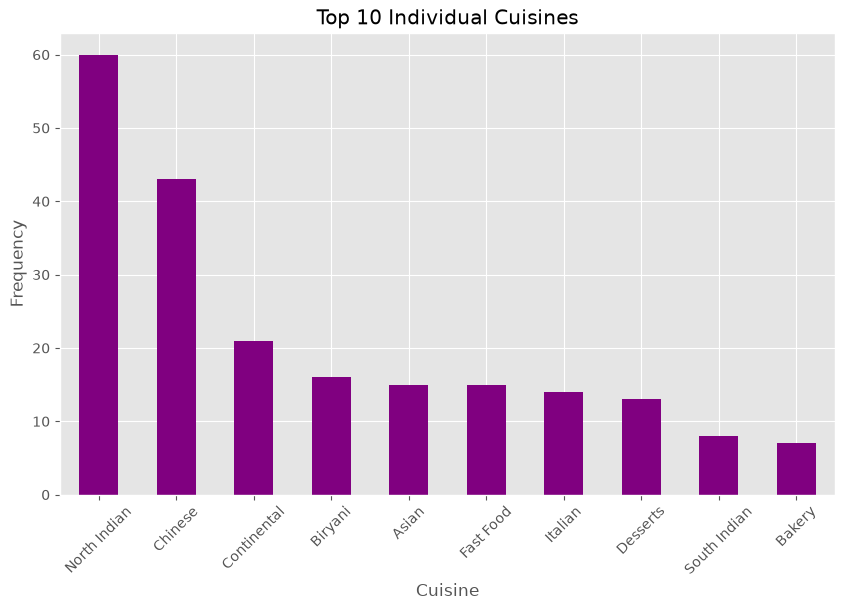

In [29]:
all_cuisine = metadata_df['Cuisines'].str.split(', ').explode()
top = all_cuisine.value_counts().head(10)

plt.figure(figsize=(10,6))
top.plot(kind='bar', color='purple')
plt.title('Top 10 Individual Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

## Observation
- North Indian cuisine is the most common cuisine in the dataset, with a frequency of 60 restaurants, indicating its high popularity.
- Chinese cuisine ranks second with 43 restaurants, making it another widely preferred cuisine.
- Continental cuisine is the third most common, appearing in 21 restaurants.
- Biryani, Asian, and Fast Food have moderate representation, each offered by around 15–16 restaurants.
- Italian and Desserts are available in a smaller number of restaurants, with frequencies of 14 and 13, respectively.
- South Indian and Bakery are the least common among the top 10 cuisines, with frequencies of 8 and 7.
- Overall, the distribution indicates that North Indian and Chinese cuisines dominate the restaurant market, while the remaining cuisines are comparatively less common.


<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
💰 EDA 6: Top 10 Most Expensive Restaurants 
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization presents the top 10 most expensive restaurants based on their average cost. It helps identify premium restaurants in the dataset.
</p>

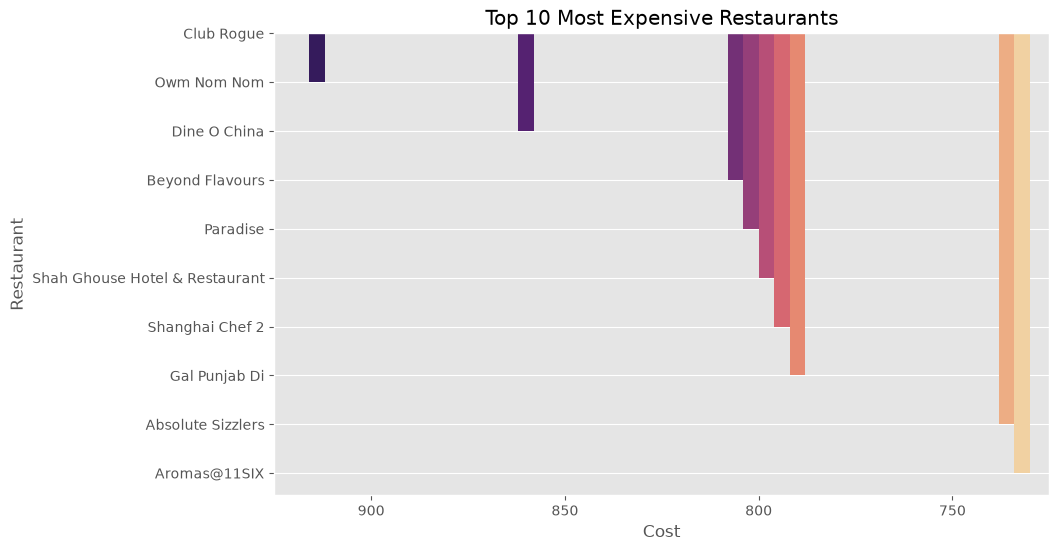

In [38]:
top_cost = metadata_df.sort_values(by='Cost', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_cost,
    x='Cost',
    y='Name',
    hue='Name',
    legend=False,
    palette='magma'
)

plt.title("Top 10 Most Expensive Restaurants")
plt.xlabel("Cost")
plt.ylabel("Restaurant")

plt.show()

## Observation:
- The top 10 restaurants cost between ₹750 and ₹900.
- Club Rogue is the most expensive, followed by Owm Nom Nom.
- The rest of the restaurants have prices that are close to each other.
- This shows that among costly restaurants, only the top 2 are noticeably more expensive — the others don't differ much in price.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🍽️ EDA 7: Average Rating by Cuisine (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization combines the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets to compare the average customer ratings across different cuisines. It helps identify which cuisines receive the highest ratings from customers.
</p>

<Axes: xlabel='Rating', ylabel='Cuisines'>

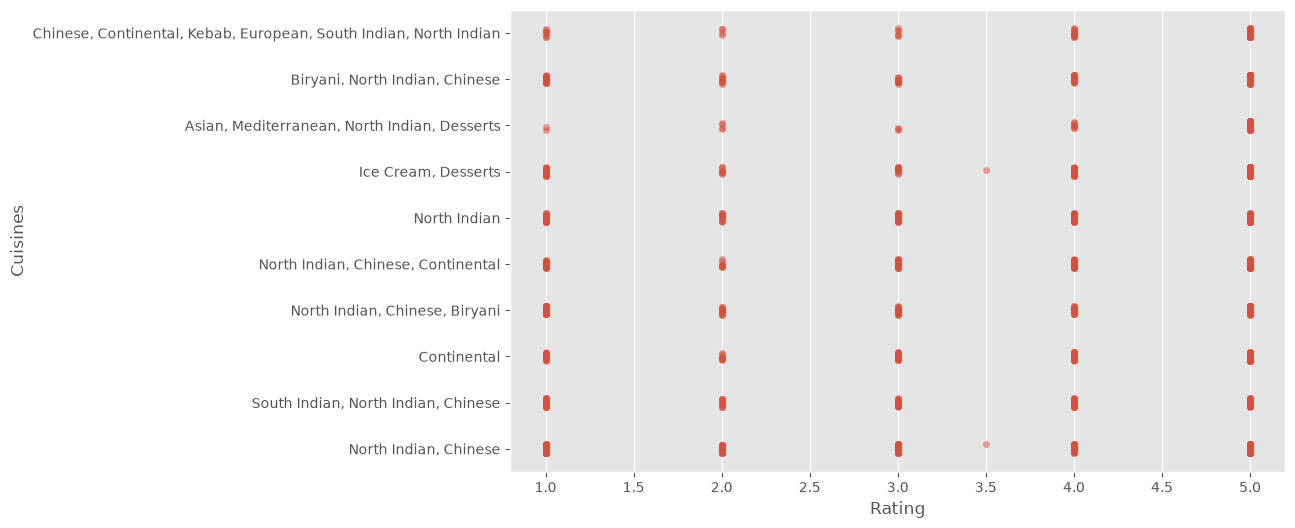

In [43]:
sns.stripplot(
    data=filtered_df,
    x='Rating',
    y='Cuisines',
    alpha=0.5
)

## Observation:
- Ratings mostly appear at fixed points (1.0, 2.0, 3.0, 4.0, 5.0) instead of spreading continuously.
- Common combinations like North Indian, Chinese, and Continental repeat across many cuisines.
- Almost all cuisines show similar rating patterns.
- No single cuisine has clearly higher or lower ratings than others.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🌳 EDA 7: Top 8 Cuisines by Review Count (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This treemap combines data from <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b>. It visualizes the top 10 cuisines based on the total number of customer reviews, helping identify the most popular cuisines among customers.
</p>

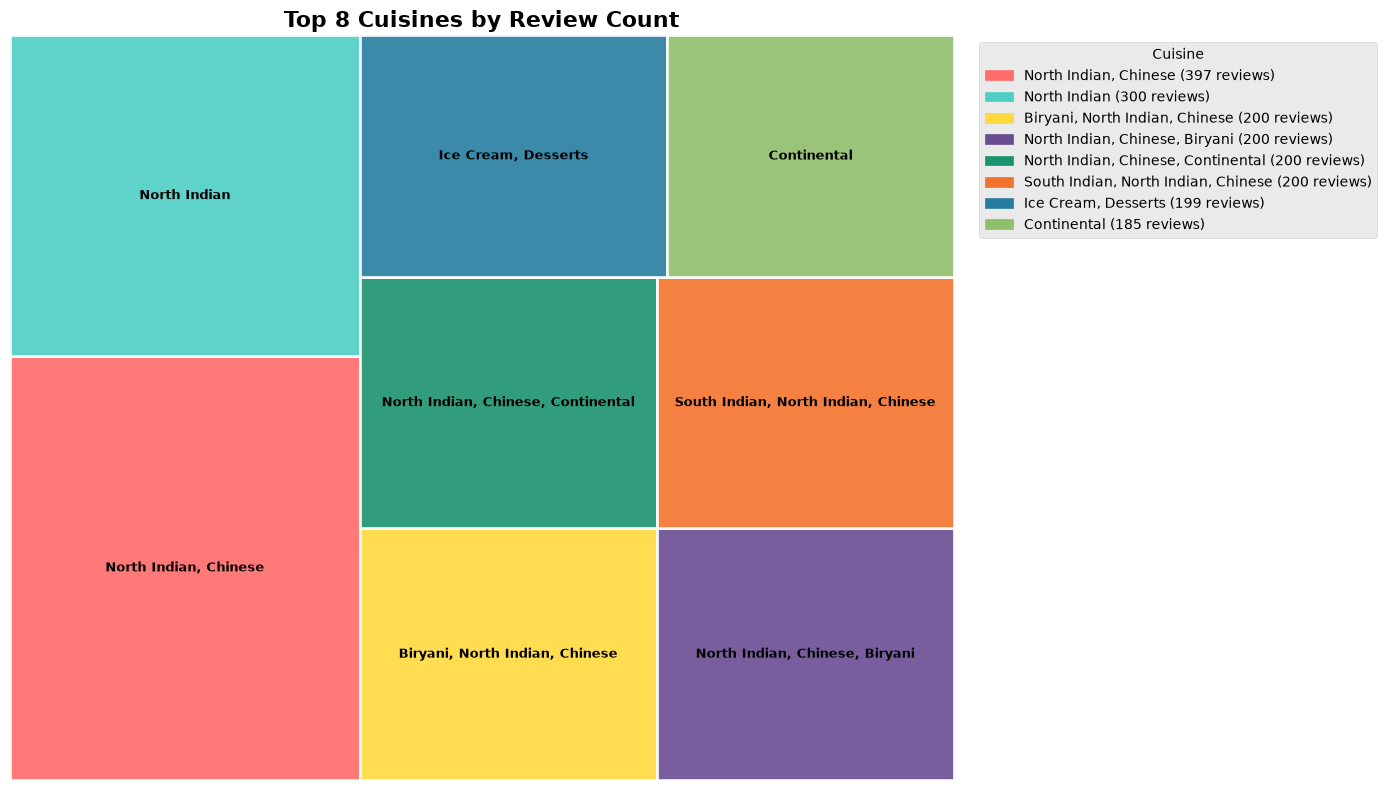

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify


merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on='Restaurant',
    right_on='Name',
    how='inner'
)


cuisine_reviews = (
    merged_df.groupby('Cuisines')
    .size()
    .sort_values(ascending=False)
    .head(8)
)


colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#FFD93D",
    "#6A4C93",
    "#1A936F",
    "#F3722C",
    "#277DA1",
    "#90BE6D"
]

plt.figure(figsize=(14,8))


squarify.plot(
    sizes=cuisine_reviews.values,
    label=cuisine_reviews.index,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=2,
    text_kwargs={
        'fontsize':9,
        'fontweight':'bold'
    }
)


handles = [
    plt.Rectangle((0,0),1,1,color=colors[i])
    for i in range(len(cuisine_reviews))
]

labels = [
    f"{name} ({count} reviews)"
    for name, count in zip(cuisine_reviews.index, cuisine_reviews.values)
]

plt.legend(
    handles,
    labels,
    title="Cuisine",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.title(
    "Top 8 Cuisines by Review Count",
    fontsize=16,
    fontweight='bold'
)

plt.axis("off")
plt.tight_layout()
plt.show()

## Observation:
- North Indian, Chinese combo has the highest reviews (397), making it the most reviewed cuisine.
- North Indian alone is also very popular, with 300 reviews.
- Multi-cuisine combinations (Biryani, North Indian, Chinese, Continental, etc.) each have around 200 reviews, showing steady demand.
- Ice Cream, Desserts and Continental are less common but still among the top 8, showing some variety in customer preference.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🎯 EDA 8: Average Customer Rating by Restaurant Collection (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization combines the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets to compare the average customer ratings across different restaurant collections. It helps identify which restaurant collections receive the highest customer satisfaction.
</p>

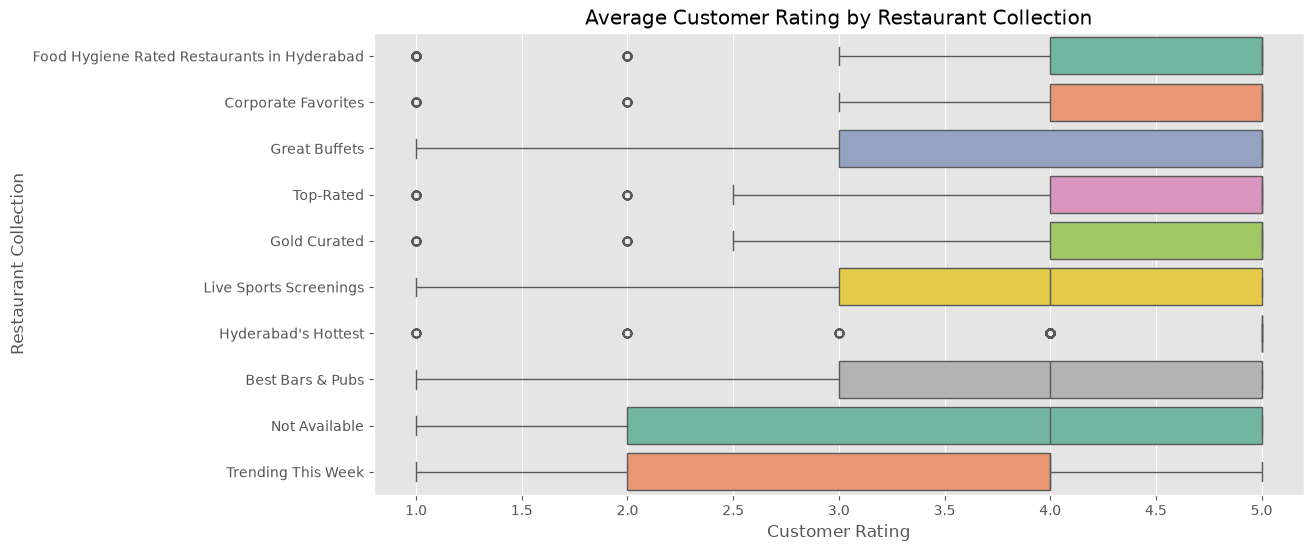

In [49]:
# Merge both datasets
merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on='Restaurant',
    right_on='Name',
    how='inner'
)

# Split multiple collections into separate rows
merged_df['Collections'] = merged_df['Collections'].fillna('Unknown')
merged_df['Collections'] = merged_df['Collections'].str.split(', ')

merged_df = merged_df.explode('Collections')

# Top 10 collections
top_collections = merged_df['Collections'].value_counts().head(10).index

filtered_df = merged_df[merged_df['Collections'].isin(top_collections)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=filtered_df,
    x='Rating',
    y='Collections',
    palette='Set2'
)

plt.title("Average Customer Rating by Restaurant Collection")
plt.xlabel("Customer Rating")
plt.ylabel("Restaurant Collection")

plt.show()

## Observation:
- Collections like Top-Rated, Gold Curated, Corporate Favorites, and Food Hygiene Rated have the highest average ratings (close to 4.0-4.5).
- Categories like Trending This Week, Not Available, and Best Bars & Pubs have lower average ratings (around 2.0-3.0).
- Great Buffets and Live Sports Screenings fall in the mid-range (around 3.0-4.0).
- This shows that curated or quality-focused collections tend to have better ratings than general or activity-based collections.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
⏰ EDA 9: Average Customer Rating by Review Hour 
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization analyzes the relationship between the review posting time and the average customer rating using the <b>Zomato Restaurant reviews.csv</b> dataset along with restaurant information from <b>Zomato Restaurant names and Metadata.csv</b>. It helps identify whether customer ratings vary throughout different hours of the day.
</p>

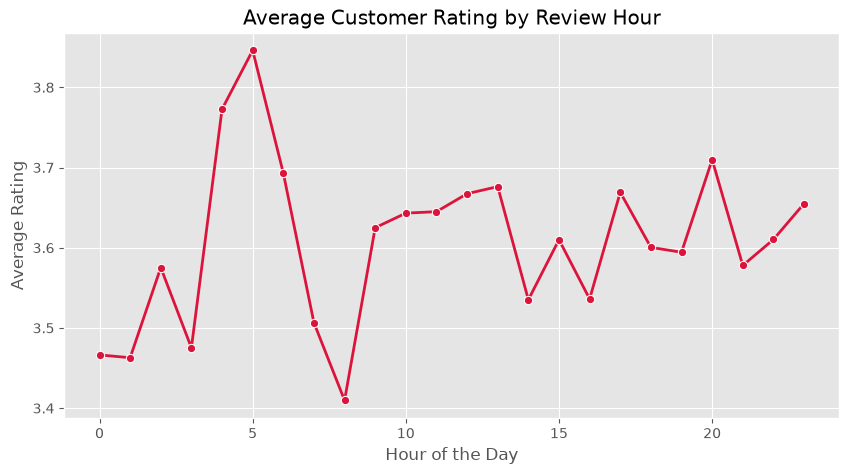

In [50]:

merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on='Restaurant',
    right_on='Name',
    how='inner'
)


merged_df['Time'] = pd.to_datetime(merged_df['Time'], errors='coerce')


merged_df['Hour'] = merged_df['Time'].dt.hour


hour_rating = merged_df.groupby('Hour')['Rating'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hour_rating,
    x='Hour',
    y='Rating',
    marker='o',
    linewidth=2,
    color='crimson'
)

plt.title("Average Customer Rating by Review Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Rating")

plt.grid(True)

plt.show()

## Observation:
- Ratings peak sharply around hour 5, reaching the highest average (close to 3.9).
- A sudden drop is seen around hour 8, where rating falls to the lowest point (~3.4).
- After hour 9, ratings stay fairly stable, fluctuating mildly between 3.5 and 3.7.
- Overall, early morning hours show more fluctuation, while later hours show a more consistent rating pattern.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
💰 EDA 10: Number of Customer Reviews by Restaurant Cost Category (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization combines the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets to compare the number of customer reviews across different restaurant cost categories.
</p>

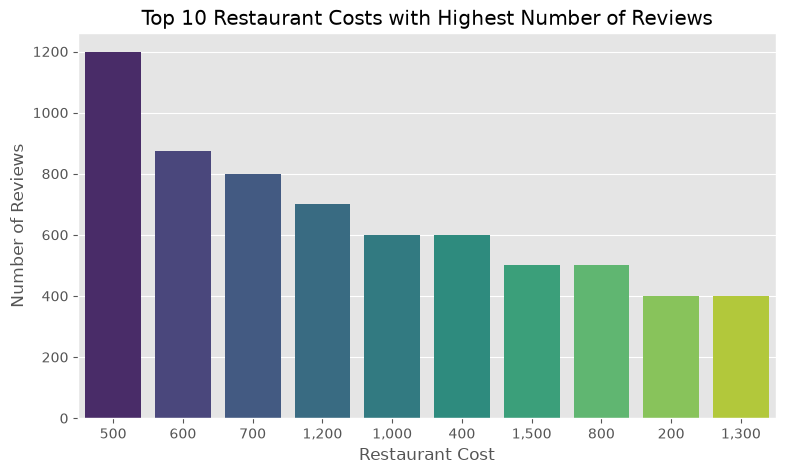

In [55]:
review_cost = (
    merged_df.groupby('Cost')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=review_cost.index.astype(str),
    y=review_cost.values,
    hue=review_cost.index.astype(str),
    legend=False,
    palette="viridis"
)

plt.title("Top 10 Restaurant Costs with Highest Number of Reviews")
plt.xlabel("Restaurant Cost")
plt.ylabel("Number of Reviews")

plt.show()

## Observation:
- Restaurants with cost ₹500 have the highest number of reviews (around 1200), showing strong customer preference for affordable options.
- As cost increases, the number of reviews generally decreases.
- Mid-range costs (₹600-1200) still get a fair number of reviews, showing moderate popularity.
- Higher-cost restaurants (₹1500, ₹1300) have comparatively fewer reviews, suggesting expensive places are visited less often.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📝 EDA 11: Customer Review Length vs Rating (Zomato Restaurant Reviews.csv)
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization analyzes the relationship between the length of customer reviews and the ratings they provide. It helps understand whether customers who write longer reviews tend to give higher or lower ratings.
</p>

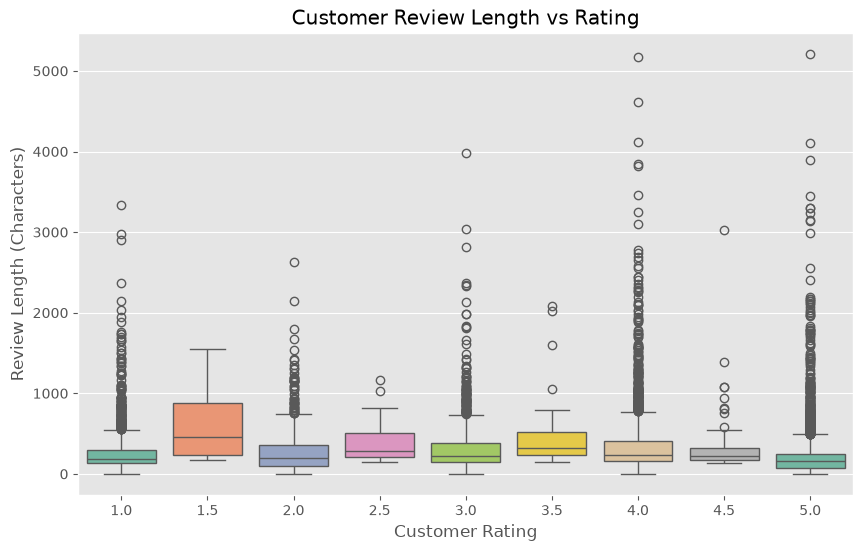

In [56]:

reviews_df['Review Length'] = reviews_df['Review'].astype(str).str.len()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=reviews_df,
    x='Rating',
    y='Review Length',
    hue='Rating',
    palette='Set2',
    legend=False
)

plt.title("Customer Review Length vs Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Review Length (Characters)")

plt.show()

## Observation:
- Most reviews are short (under 1000 characters), regardless of the rating given.
- Ratings 4.0 and 5.0 have the most outliers, meaning some customers write very long reviews for both high and low experiences.
- Rating 1.5 shows a slightly higher median review length compared to others.
- Overall, review length doesn't strongly depend on rating — both short and long reviews appear across all rating levels.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔥 EDA 12: Average Restaurant Cost by Customer Rating (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This heatmap combines data from <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> to visualize the relationship between customer ratings and the average restaurant cost. It helps identify pricing patterns across different rating levels.
</p>

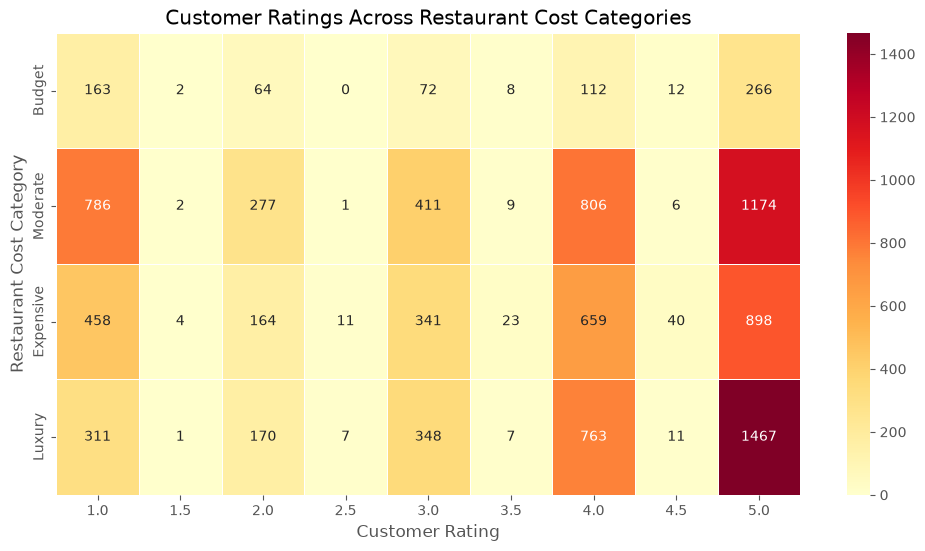

In [57]:

merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on='Restaurant',
    right_on='Name',
    how='inner'
)

merged_df['Cost'] = (
    merged_df['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)

merged_df['Cost'] = pd.to_numeric(merged_df['Cost'], errors='coerce')


merged_df = merged_df.dropna(subset=['Cost', 'Rating'])


merged_df['Cost Category'] = pd.cut(
    merged_df['Cost'],
    bins=[0, 300, 600, 1000, merged_df['Cost'].max()],
    labels=['Budget', 'Moderate', 'Expensive', 'Luxury'],
    include_lowest=True
)


heatmap_data = pd.crosstab(
    merged_df['Cost Category'],
    merged_df['Rating']
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title("Customer Ratings Across Restaurant Cost Categories")
plt.xlabel("Customer Rating")
plt.ylabel("Restaurant Cost Category")

plt.show()

## Observation:
- Rating 5.0 has the highest counts across almost all cost categories, especially in Luxury (1467) and Moderate (1174).
- Moderate and Expensive restaurants have the most reviews overall, showing they are the most commonly rated categories.
- Budget restaurants have fewer high ratings compared to other categories.
- Overall, higher ratings (4.0 and 5.0) d

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📈 EDA 13: Average Restaurant Cost by Customer Rating (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This visualization combines the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets to analyze how the average restaurant cost varies across different customer ratings.
</p>

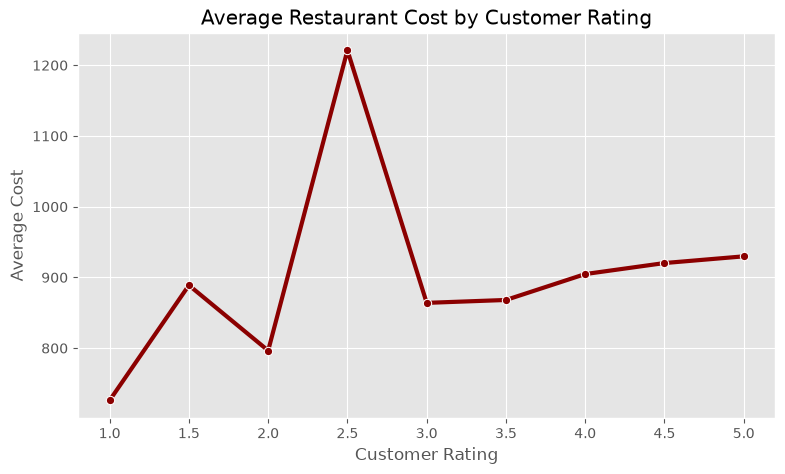

In [58]:

merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on='Restaurant',
    right_on='Name',
    how='inner'
)


merged_df['Cost'] = (
    merged_df['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)

merged_df['Cost'] = pd.to_numeric(merged_df['Cost'], errors='coerce')

merged_df = merged_df.dropna(subset=['Cost', 'Rating'])


avg_cost = merged_df.groupby('Rating')['Cost'].mean().reset_index()

plt.figure(figsize=(9,5))

sns.lineplot(
    data=avg_cost,
    x='Rating',
    y='Cost',
    marker='o',
    linewidth=3,
    color='darkred'
)

plt.title("Average Restaurant Cost by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Average Cost")

plt.grid(True)

plt.show()

## Observation:
- Rating 2.5 shows a sharp spike in average cost (around 1200), much higher than other ratings.
- Ratings 3.0 and above show a stable and gradual increase in average cost, staying between 850-900.
- Lower ratings (1.0, 2.0) have lower average costs, but rating 1.5 shows a slight rise.
- Overall, cost doesn't increase steadily with rating — the sharp spike at 2.5 suggests possible outliers or limited data at that rating.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔷 EDA 14: Restaurant Density by Cost and Customer Rating (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This hexbin plot combines the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets to visualize the density of restaurants based on their cost and customer ratings. Darker hexagons indicate a higher concentration of restaurants.
</p>

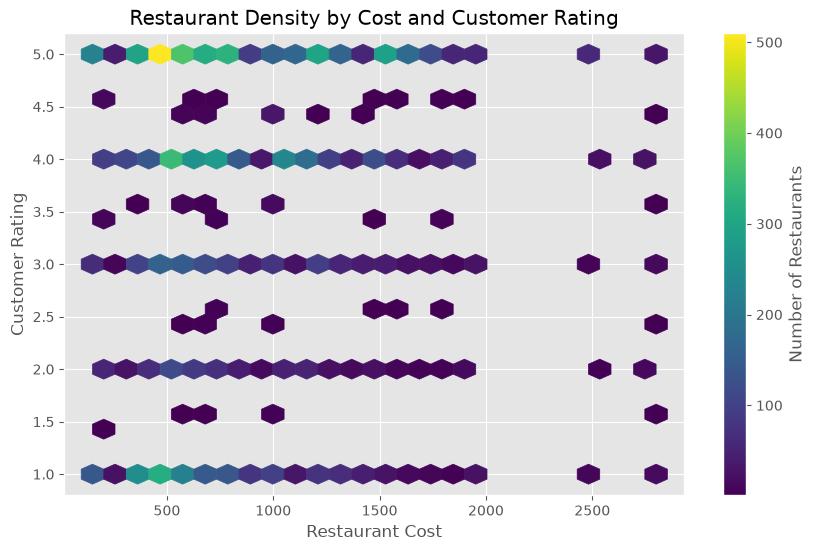

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Merge both datasets
merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on="Restaurant",
    right_on="Name",
    how="inner"
)

# Convert Cost to numeric
merged_df['Cost'] = (
    merged_df['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)

merged_df['Cost'] = pd.to_numeric(merged_df['Cost'], errors='coerce')


merged_df = merged_df.dropna(subset=['Cost', 'Rating'])

plt.figure(figsize=(10,6))

plt.hexbin(
    merged_df['Cost'],
    merged_df['Rating'],
    gridsize=25,
    cmap='viridis',
    mincnt=1
)

plt.colorbar(label='Number of Restaurants')

plt.title("Restaurant Density by Cost and Customer Rating")
plt.xlabel("Restaurant Cost")
plt.ylabel("Customer Rating")

plt.show()

## Observation:
- Most restaurants are concentrated at rating levels 1.0, 2.0, 3.0, 4.0, and 5.0, showing customers usually give round-number ratings.
- The highest restaurant density is seen at rating 5.0 with cost around ₹300-500 (bright yellow-green hexagon).
- Restaurant cost mostly lies between ₹500 and ₹2000, with very few restaurants above ₹2500.
- Ratings like 1.5, 2.5, 3.5, and 4.5 have much lower density, meaning customers rarely give half-point ratings.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📈 EDA 15: Density Distribution of Restaurant Cost (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This Kernel Density Estimation (KDE) plot visualizes the distribution of restaurant costs after combining the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets. It provides a smooth representation of how restaurant costs are distributed.
</p>

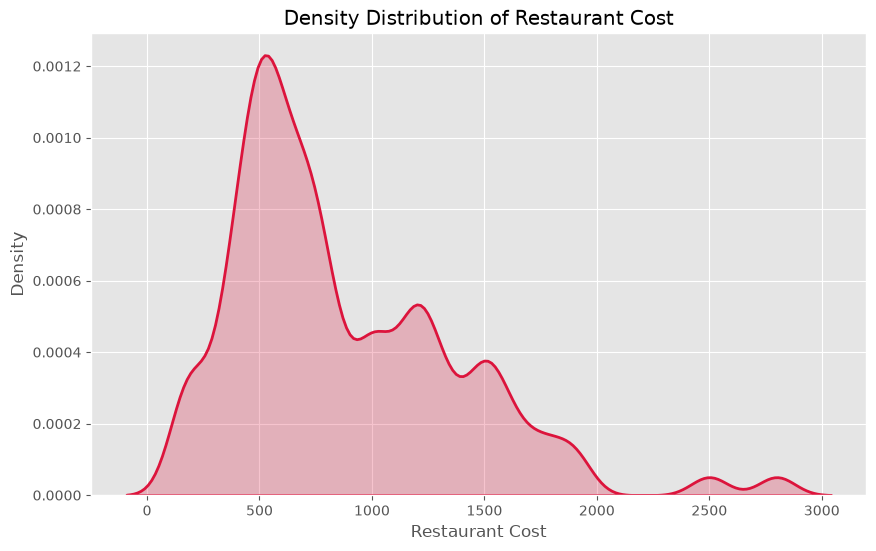

In [60]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=merged_df,
    x='Cost',
    fill=True,
    color='crimson',
    linewidth=2
)

plt.title("Density Distribution of Restaurant Cost")
plt.xlabel("Restaurant Cost")
plt.ylabel("Density")

plt.show()

## Observation:
- Most restaurants have a cost around ₹500, shown by the tallest peak in the graph.
- Smaller peaks appear near ₹1200 and ₹1500, showing some restaurants also cluster at these price points.
- Very few restaurants have costs above ₹2000, and the density is almost flat beyond ₹2500.
- Overall, the distribution is positively skewed, meaning affordable restaurants are far more common than expensive ones.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📊 EDA 16: Pairwise Relationship Between Numerical Features (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This pairplot combines the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets to visualize the pairwise relationships between numerical features such as customer ratings, restaurant cost, and pictures. It helps identify trends, distributions, and potential correlations among these variables.
</p>

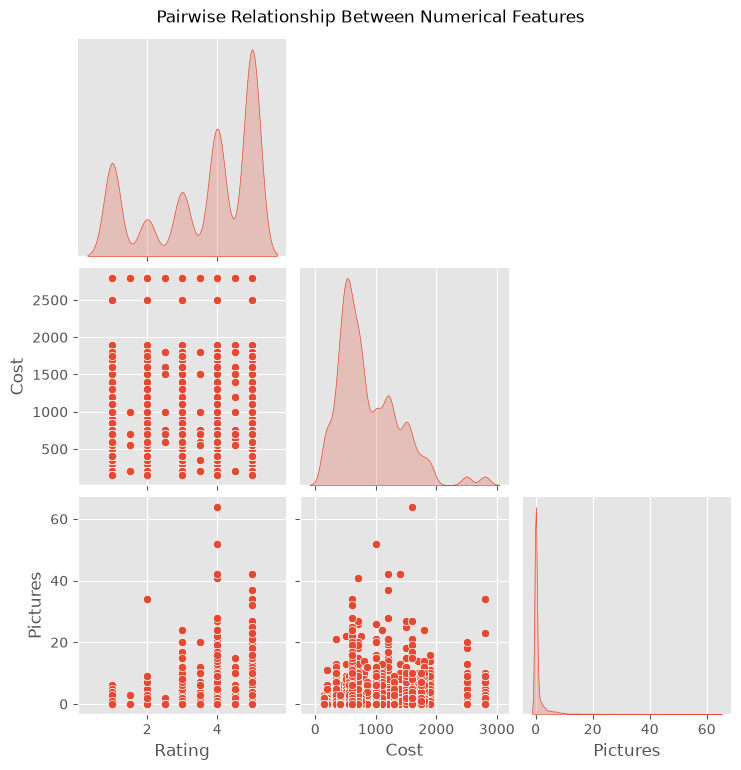

In [61]:

merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on="Restaurant",
    right_on="Name",
    how="inner"
)

merged_df['Cost'] = (
    merged_df['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)

merged_df['Cost'] = pd.to_numeric(merged_df['Cost'], errors='coerce')


pairplot_df = merged_df[['Rating', 'Cost', 'Pictures']].dropna()

sns.pairplot(
    pairplot_df,
    diag_kind='kde',
    corner=True
)

plt.suptitle("Pairwise Relationship Between Numerical Features", y=1.02)

plt.show()

## Observation:
- Rating values are mostly concentrated at fixed points (like 3, 4, 4.5), rather than spread continuously.
- Most restaurants have a cost between ₹500-1500, with fewer restaurants above ₹2500.
- The number of pictures uploaded is mostly low (0-20), with only a few restaurants having very high picture counts.
- No strong linear relationship is visible between rating, cost, and pictures — high cost or high rating doesn't necessarily mean more pictures.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔥 EDA 17: Correlation Analysis of Numerical Features (Combined Dataset)
</h2>

<p style="font-size:16px; line-height:1.8;">
This heatmap combines the <b>Zomato Restaurant reviews.csv</b> and <b>Zomato Restaurant names and Metadata.csv</b> datasets to display the correlation between numerical features. It helps identify the strength and direction of relationships among customer ratings, restaurant cost, and pictures.
</p>

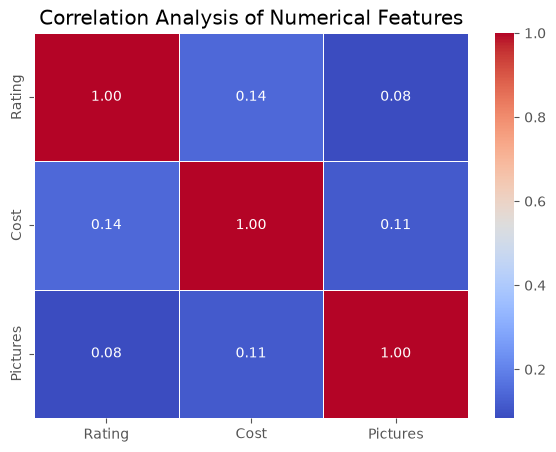

In [62]:

merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on="Restaurant",
    right_on="Name",
    how="inner"
)

merged_df['Cost'] = (
    merged_df['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)

merged_df['Cost'] = pd.to_numeric(merged_df['Cost'], errors='coerce')

corr_df = merged_df[['Rating', 'Cost', 'Pictures']].dropna()


corr = corr_df.corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Analysis of Numerical Features")

plt.show()

## Observation:
- Rating and Cost have a very weak correlation (0.14), meaning higher cost doesn't strongly mean higher rating.
- Rating and Pictures show almost no correlation (0.08).
- Cost and Pictures also show a weak correlation (0.11).
- Overall, none of the numerical features are strongly related to each other — each acts fairly independently.

## Conclusion:

- This EDA was done on Zomato restaurant data (Cost, Rating, Cuisine, Reviews, Pictures, Collections) to find patterns before applying ML clustering.
- Most restaurants fall in the budget to moderate price range (₹300–₹1500); expensive and luxury restaurants are very few.
- Customer ratings are mostly between 3.0 and 5.0, showing overall positive feedback.
- A few restaurants have very high cost (above ₹2500), but they are outliers and not common.
- Cost and Rating have very weak correlation, meaning higher price doesn't guarantee better rating.
- Review length and number of pictures also don't strongly affect rating.
- North Indian and Chinese cuisines are the most popular and most reviewed combinations.
- Multi-cuisine restaurants (like Biryani, North Indian, Chinese) also get a good number of reviews.
- Curated collections (Top-Rated, Gold Curated, Corporate Favorites) have better average ratings than general collections (Trending, Not Available).
- Review activity changes by hour of the day, but no strong pattern connects time with rating.
- Higher ratings (4.0 and 5.0) are common across all cost categories, not just expensive ones.
- Most reviews are short in length, regardless of the rating given.
- Overall, customer satisfaction depends more on food quality and cuisine type than on price or visibility.
- These insights will help build better ML clustering models, since features like cuisine, collection type, and rating patterns matter more than cost alone.
- This analysis also helps identify which features are useful for grouping restaurants meaningfully (e.g., budget-friendly & highly rated vs premium & average rated).